# GNN 사기 탐지 — 06. Final: CARE-HAN + CatBoost Hybrid

## 설계 개요

| 항목 | 설계 |
|------|------|
| **노드** | Review (78-dim) · User (12-dim) · Restaurant (6-dim) = 3종 |
| **엣지** | R-Sim-R · U-writes-R · P-about-R · U-collude-U = 4관계 |
| **GNN** | CARE-HAN: Semantic Attention + Trust-Aware CARE 게이트 |
| **하이브리드** | GNN 임베딩(128) + 원시 피처(78) → CatBoost |

## 단계별 고도화 흐름 (학술제 제출 구조)

| 단계 | 노트북 | 모델 | 핵심 특징 |
|------|--------|------|-----------|
| **04** | `04_Baseline` | ReviewRGCN | 동질 그래프, 2관계(R-S-R·R-Sim-R), Review 노드 1종 |
| **05** | `05_Model_Training` | **PC-GNN** *(예선 제출)* | 4관계, Chooser 어텐션, Picker 샘플링, FocalLoss |
| **06** | `06_HIN_CARE_Model` | **CARE-HAN** | 3종 노드 HIN, Trust-Aware CARE 게이트, Semantic Attention |
| **06+** | `06_HIN_CARE_Model` | **CARE-HAN + CatBoost** *(최종)* | GNN 임베딩(128) + 원시 피처(78) 하이브리드 |

결과는 `results_06.json`으로 저장됩니다.

In [1]:
# [01] 임포트 및 환경 설정
import os, sys, warnings
import json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import platform
_font = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'DejaVu Sans')
matplotlib.rcParams['font.family'] = _font
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import average_precision_score, f1_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print('CatBoost 사용 가능')
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost 미설치 — GNN 단독 평가만 진행합니다.')
    print('   pip install catboost')

BASE_DIR = os.getcwd()
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {device} | PyTorch: {torch.__version__}')

CatBoost 사용 가능
디바이스: cpu | PyTorch: 2.11.0+cpu


In [2]:
# [02] 하이퍼파라미터 설정
CFG = {
    'test_size'      : 0.20,
    'val_size'       : 0.20,
    'random_state'   : 42,
    'rsim_thr'       : 0.70,
    'collude_days'   : 7,
    'tfidf_features' : 5000,
    'svd_dim'        : 64,
    'hidden_dim'     : 128,
    'n_layers'       : 2,
    'dropout'        : 0.30,
    'care_temp'      : 0.10,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'epochs'         : 100,
    'patience'       : 10,
    'cb_iterations'  : 1000,
    'cb_depth'       : 6,
    'cb_lr'          : 0.05,
}
print('CFG 설정 완료')
print(f'  hidden_dim={CFG["hidden_dim"]}, n_layers={CFG["n_layers"]}, rsim_thr={CFG["rsim_thr"]}')

CFG 설정 완료
  hidden_dim=128, n_layers=2, rsim_thr=0.7


In [3]:
# [03] 데이터 로드 및 글로벌 인덱스 구성
df         = pd.read_parquet('yelpzip_sampled.parquet')
df_rating  = pd.read_csv('features_rating.csv')
df_burst   = pd.read_csv('burst_features.csv')
df_textsim = pd.read_csv('custom_edges_textSim.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.reset_index(drop=True)

# 파생 피처 병합
df = df.merge(
    df_rating[['user_id','prod_id','rating_deviation','norm_rating_entropy',
               'is_cold_start','is_single_review']],
    on=['user_id','prod_id'], how='left'
)
df = df.merge(
    df_burst[['user_id','user_burst_max7d','user_burst_ratio']],
    on='user_id', how='left'
)
df['user_burst_max7d'] = df['user_burst_max7d'].fillna(0)
df['user_burst_ratio'] = df['user_burst_ratio'].fillna(0)

# 글로벌 노드 인덱스 매핑
unique_users = df['user_id'].unique()
unique_prods = df['prod_id'].unique()
N_R = len(df)
N_U = len(unique_users)
N_P = len(unique_prods)

user2idx = {u: i for i, u in enumerate(unique_users)}
prod2idx = {p: i for i, p in enumerate(unique_prods)}
df['u_idx'] = df['user_id'].map(user2idx)
df['p_idx'] = df['prod_id'].map(prod2idx)

user_start   = N_R
rest_start   = N_R + N_U
N_total      = N_R + N_U + N_P
node_offsets = (N_R, user_start, rest_start, N_total)

print(f'리뷰 노드: {N_R:,}  유저 노드: {N_U:,}  식당 노드: {N_P:,}')
print(f'전체 노드: {N_total:,}')
print(f'사기 비율: {df["label"].mean():.3f}')
print(f'Review[0..{N_R-1}], User[{user_start}..{rest_start-1}], Rest[{rest_start}..{N_total-1}]')

리뷰 노드: 50,950  유저 노드: 17,439  식당 노드: 200
전체 노드: 68,589
사기 비율: 0.248
Review[0..50949], User[50950..68388], Rest[68389..68588]


In [4]:
# [04] 텍스트 피처 추출 (7개 — 04 Baseline과 동일)
MENU_WORDS = {
    'chicken','beef','pizza','salad','pasta','fish','shrimp','steak',
    'burger','sandwich','soup','rice','noodles','sushi','tacos','bread',
    'cake','dessert','cheese','bacon','turkey','salmon','lobster','crab',
    'pork','lamb','duck','tofu','mushroom','fries','wings','ribs',
    'brisket','sausage','waffle','pancake','curry','ramen','pho',
    'gyoza','tempura','dumplings','kebab','burrito','nachos'
}
POS_WORDS = {
    'great','amazing','delicious','excellent','wonderful','fantastic',
    'outstanding','superb','brilliant','perfect','awesome','incredible',
    'lovely','magnificent','terrific','fabulous'
}
NEG_WORDS = {
    'bad','terrible','awful','horrible','disgusting','dreadful','poor',
    'disappointing','mediocre','tasteless','bland','rude','slow',
    'dirty','overpriced','waste','worst'
}

def extract_text_features(texts):
    rows = []
    for text in texts:
        text = str(text)
        words = text.split()
        n = max(len(words), 1)
        chars = max(len(text), 1)
        unique_words = set(w.lower().strip('.,!?') for w in words)
        pos  = sum(1 for w in words if w.lower().strip('.,!?') in POS_WORDS)
        neg  = sum(1 for w in words if w.lower().strip('.,!?') in NEG_WORDS)
        menu = sum(1 for w in words if w.lower().strip('.,!?') in MENU_WORDS)
        rows.append({
            'text_len'     : len(text),
            'word_count'   : len(words),
            'digit_ratio'  : sum(c.isdigit() for c in text) / chars,
            'menu_mentions': float(menu),
            'special_ratio': sum(not c.isalnum() and not c.isspace() for c in text) / chars,
            'ttr'          : len(unique_words) / n,
            'sentiment'    : (pos - neg) / n,
        })
    return pd.DataFrame(rows)

print('텍스트 피처 추출 중...')
text_feats = extract_text_features(df['text'].fillna(''))
for c in text_feats.columns:
    df[c] = text_feats[c].values

# RPR 의심 점수 (같은 유저가 같은 식당에 복수 리뷰)
rpr_cnt = df.groupby(['user_id','prod_id']).size().reset_index(name='rpr_cnt')
df = df.merge(rpr_cnt, on=['user_id','prod_id'], how='left')
df['rpr_suspicion'] = (df['rpr_cnt'] > 1).astype(float)
df = df.drop(columns=['rpr_cnt'])

# 날짜 파생변수
df['weekday'] = df['date'].dt.weekday
df['month']   = df['date'].dt.month

print(f'텍스트 피처 완료: {text_feats.shape}')

텍스트 피처 추출 중...
텍스트 피처 완료: (50950, 7)


In [5]:
# [05] TF-IDF + TruncatedSVD 텍스트 임베딩 (64차원)
print('TF-IDF 벡터화 중...')
tfidf = TfidfVectorizer(
    max_features=CFG['tfidf_features'],
    min_df=2,
    strip_accents='unicode',
    sublinear_tf=True
)
tfidf_mat = tfidf.fit_transform(df['text'].fillna(''))

svd = TruncatedSVD(n_components=CFG['svd_dim'], random_state=CFG['random_state'])
text_emb = svd.fit_transform(tfidf_mat)  # (N_R, 64)

print(f'TF-IDF: {tfidf_mat.shape}  ->  SVD: {text_emb.shape}')
print(f'분산 설명률: {svd.explained_variance_ratio_.sum():.3f}')

TF-IDF 벡터화 중...
TF-IDF: (50950, 5000)  ->  SVD: (50950, 64)
분산 설명률: 0.148


In [6]:
# [06] Train / Val / Test 분할 (04/05와 동일 시드 — 공정 비교)
labels  = df['label'].values
rev_idx = np.arange(N_R)

idx_trainval, idx_test = train_test_split(
    rev_idx,
    test_size=CFG['test_size'],
    random_state=CFG['random_state'],
    stratify=labels
)
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=CFG['val_size'],
    random_state=CFG['random_state'],
    stratify=labels[idx_trainval]
)

train_mask = torch.zeros(N_R, dtype=torch.bool)
val_mask   = torch.zeros(N_R, dtype=torch.bool)
test_mask  = torch.zeros(N_R, dtype=torch.bool)
train_mask[idx_train] = True
val_mask[idx_val]     = True
test_mask[idx_test]   = True

print(f'Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}')
print(f'Train 사기 비율: {labels[idx_train].mean():.3f}')
print(f'Test  사기 비율: {labels[idx_test].mean():.3f}')

Train: 32,608  Val: 8,152  Test: 10,190
Train 사기 비율: 0.248
Test  사기 비율: 0.248


In [7]:
# [07] 리뷰 노드 피처 (78-dim = 14 수치 + 64 SVD)
FEAT_COLS = [
    'rating', 'weekday', 'month',
    'rating_deviation', 'is_cold_start', 'is_single_review',
    'rpr_suspicion',
    'text_len', 'word_count', 'digit_ratio', 'menu_mentions',
    'special_ratio', 'ttr', 'sentiment',
]
for c in FEAT_COLS:
    df[c] = df[c].fillna(0).astype(float)

feat_manual = df[FEAT_COLS].values          # (N_R, 14)
x_rev       = np.hstack([feat_manual, text_emb])  # (N_R, 78)
in_dim_rev  = x_rev.shape[1]

print(f'리뷰 노드 피처: {x_rev.shape}  (in_dim={in_dim_rev})')

리뷰 노드 피처: (50950, 78)  (in_dim=78)


In [8]:
# [08] 유저 노드 피처 (12-dim) — Train 기준 계산으로 데이터 누수 방지
df_tr = df.iloc[idx_train].copy()

# 기본 통계
user_stats = df_tr.groupby('user_id').agg(
    user_review_count=('label', 'count'),
    user_fraud_ratio =('label', 'mean'),
    user_avg_rating  =('rating', 'mean'),
    user_rating_std  =('rating', 'std'),
).reset_index()

# 활동 기간 (일)
act = df_tr.groupby('user_id')['date'].agg(
    lambda x: (x.max() - x.min()).days
).reset_index()
act.columns = ['user_id', 'activity_span']
user_stats = user_stats.merge(act, on='user_id', how='left')

# 리뷰 간격 통계
def _interval(dates):
    s = sorted(dates)
    if len(s) < 2:
        return 0.0, 0.0
    diffs = [(s[i+1] - s[i]).days for i in range(len(s) - 1)]
    return float(np.mean(diffs)), float(np.std(diffs) if len(diffs) > 1 else 0.0)

iv = df_tr.groupby('user_id')['date'].apply(_interval).reset_index()
iv[['interval_mean','interval_std']] = pd.DataFrame(iv['date'].tolist(), index=iv.index)
iv = iv.drop(columns=['date'])
user_stats = user_stats.merge(iv, on='user_id', how='left')

# 방문 식당 다양성
pdiv = df_tr.groupby('user_id')['prod_id'].nunique().reset_index()
pdiv.columns = ['user_id', 'prod_diversity']
user_stats = user_stats.merge(pdiv, on='user_id', how='left')

# Burst + Entropy 병합
user_stats = user_stats.merge(
    df_burst[['user_id','user_burst_max7d','user_burst_ratio']], on='user_id', how='left'
)
ent_tmp = df[['user_id','norm_rating_entropy']].drop_duplicates('user_id')
user_stats = user_stats.merge(ent_tmp, on='user_id', how='left')

# Trust score: 활동기간 + 리뷰수 기반 0~1
user_stats['activity_span'] = user_stats['activity_span'].fillna(0)
user_stats['trust_score'] = (
    np.clip(user_stats['activity_span'] / 365, 0, 1) * 0.5 +
    np.clip(user_stats['user_review_count'] / 10, 0, 1) * 0.5
)

# 전체 유저 포함 (테스트 유저도 추론 가능하도록)
all_users  = pd.DataFrame({'user_id': unique_users})
user_stats = all_users.merge(user_stats, on='user_id', how='left')
U_COLS = [
    'user_review_count','user_fraud_ratio','user_avg_rating','user_rating_std',
    'activity_span','interval_mean','interval_std','prod_diversity',
    'user_burst_max7d','user_burst_ratio','norm_rating_entropy','trust_score'
]
user_stats[U_COLS] = user_stats[U_COLS].fillna(0)
x_usr     = user_stats[U_COLS].values.astype(float)  # (N_U, 12)
in_dim_usr = x_usr.shape[1]

print(f'유저 노드 피처: {x_usr.shape}  (in_dim={in_dim_usr})')
print(user_stats[U_COLS].describe().round(3))

유저 노드 피처: (17439, 12)  (in_dim=12)
       user_review_count  user_fraud_ratio  user_avg_rating  user_rating_std  \
count          17439.000         17439.000        17439.000        17439.000   
mean               1.870             0.389            3.176            0.295   
std                2.217             0.486            1.818            0.501   
min                0.000             0.000            0.000            0.000   
25%                1.000             0.000            2.000            0.000   
50%                1.000             0.000            4.000            0.000   
75%                2.000             1.000            4.500            0.577   
max               37.000             1.000            5.000            2.828   

       activity_span  interval_mean  interval_std  prod_diversity  \
count      17439.000      17439.000     17439.000       17439.000   
mean          76.739         34.615        14.660           1.870   
std          157.082         79.976  

In [9]:
# [09] 식당 노드 피처 (6-dim) — Train 기준 계산
prod_stats = df_tr.groupby('prod_id').agg(
    prod_avg_rating  =('rating', 'mean'),
    prod_rating_std  =('rating', 'std'),
    prod_review_count=('label', 'count'),
    prod_fraud_ratio =('label', 'mean'),
).reset_index()

# 버스트 유저 비율 (7일 내 max 3건 이상인 유저)
burst_set = set(df_burst[df_burst['user_burst_max7d'] >= 3]['user_id'].tolist())
df['_is_burst'] = df['user_id'].isin(burst_set).astype(float)
burst_prod = df.groupby('prod_id')['_is_burst'].mean().reset_index()
burst_prod.columns = ['prod_id', 'prod_burst_user_ratio']
prod_stats = prod_stats.merge(burst_prod, on='prod_id', how='left')
df.drop(columns=['_is_burst'], inplace=True)

# 콜드 스타트 (트레인 기준 10건 미만)
prod_stats['is_cold_start_prod'] = (prod_stats['prod_review_count'] < 10).astype(float)

all_prods  = pd.DataFrame({'prod_id': unique_prods})
prod_stats = all_prods.merge(prod_stats, on='prod_id', how='left')
P_COLS = [
    'prod_avg_rating','prod_rating_std','prod_review_count',
    'prod_fraud_ratio','prod_burst_user_ratio','is_cold_start_prod'
]
prod_stats[P_COLS] = prod_stats[P_COLS].fillna(0)
x_prod      = prod_stats[P_COLS].values.astype(float)  # (N_P, 6)
in_dim_prod = x_prod.shape[1]

print(f'식당 노드 피처: {x_prod.shape}  (in_dim={in_dim_prod})')
print(prod_stats[P_COLS].describe().round(3))

식당 노드 피처: (200, 6)  (in_dim=6)
       prod_avg_rating  prod_rating_std  prod_review_count  prod_fraud_ratio  \
count          200.000          200.000            200.000           200.000   
mean             3.961            0.988            163.040             0.230   
std              0.276            0.140            123.022             0.129   
min              2.708            0.669             45.000             0.055   
25%              3.810            0.894            101.000             0.145   
50%              3.968            0.969            122.500             0.198   
75%              4.146            1.073            175.500             0.267   
max              4.507            1.609           1017.000             0.761   

       prod_burst_user_ratio  is_cold_start_prod  
count                200.000               200.0  
mean                   0.017                 0.0  
std                    0.016                 0.0  
min                    0.000                

In [10]:
# [10] 글로벌 인덱스 기반 4종 엣지 구성
print('엣지 구성 중...')
r_idx_all = df.index.values
u_glob    = df['u_idx'].values + user_start   # 글로벌 유저 인덱스
p_glob    = df['p_idx'].values + rest_start   # 글로벌 식당 인덱스

# ---- 엣지 1: R-Sim-R (텍스트 유사도 임계값 이상, 양방향) ----
sim_mask = df_textsim['text_similarity'] >= CFG['rsim_thr']
src_sim  = df_textsim.loc[sim_mask, 'src_review_idx'].values
dst_sim  = df_textsim.loc[sim_mask, 'dst_review_idx'].values
edge_sim  = torch.tensor(
    np.stack([np.concatenate([src_sim, dst_sim]),
              np.concatenate([dst_sim, src_sim])], axis=0),
    dtype=torch.long
)

# ---- 엣지 2: U-writes-R (유저-리뷰 양방향) ----
edge_writes = torch.tensor(
    np.stack([np.concatenate([u_glob, r_idx_all]),
              np.concatenate([r_idx_all, u_glob])], axis=0),
    dtype=torch.long
)

# ---- 엣지 3: P-about-R (식당-리뷰 양방향) ----
edge_about = torch.tensor(
    np.stack([np.concatenate([p_glob, r_idx_all]),
              np.concatenate([r_idx_all, p_glob])], axis=0),
    dtype=torch.long
)

# ---- 엣지 4: U-collude-U (같은 식당, 7일 이내 다른 유저 쌍) ----
print('공모 엣지 탐색 중 (시간 소요 가능)...')
collude_pairs = set()
df_sorted = df.sort_values(['prod_id', 'date']).reset_index(drop=True)
for pid, grp in df_sorted.groupby('prod_id'):
    u_arr = grp['u_idx'].values
    d_arr = grp['date'].values.astype('datetime64[D]').astype(np.int64)
    n = len(grp)
    for i in range(n):
        for j in range(i + 1, n):
            if int(d_arr[j] - d_arr[i]) > CFG['collude_days']:
                break
            if u_arr[i] != u_arr[j]:
                a = int(min(u_arr[i], u_arr[j]))
                b = int(max(u_arr[i], u_arr[j]))
                collude_pairs.add((a, b))

if collude_pairs:
    cs_arr = np.array([p[0] for p in collude_pairs], dtype=np.int64) + user_start
    cd_arr = np.array([p[1] for p in collude_pairs], dtype=np.int64) + user_start
    edge_collude = torch.tensor(
        np.stack([np.concatenate([cs_arr, cd_arr]),
                  np.concatenate([cd_arr, cs_arr])], axis=0),
        dtype=torch.long
    )
else:
    # 엣지 없을 때 유저 셀프 루프 (메시지 패싱 안정화)
    u_range = torch.arange(user_start, rest_start, dtype=torch.long)
    edge_collude = torch.stack([u_range, u_range], dim=0)

rsim_thr_val = CFG['rsim_thr']
collude_days_val = CFG['collude_days']
print(f'엣지 구성 완료')
print(f'  R-Sim-R    : {edge_sim.shape[1]:>8,}개  (유사도>={rsim_thr_val})')
print(f'  U-writes-R : {edge_writes.shape[1]:>8,}개  (양방향)')
print(f'  P-about-R  : {edge_about.shape[1]:>8,}개  (양방향)')
print(f'  U-collude-U: {edge_collude.shape[1]:>8,}개  ({len(collude_pairs)} 쌍)')

엣지 구성 중...
공모 엣지 탐색 중 (시간 소요 가능)...
엣지 구성 완료
  R-Sim-R    :  319,670개  (유사도>=0.7)
  U-writes-R :  101,900개  (양방향)
  P-about-R  :  101,900개  (양방향)
  U-collude-U:  456,626개  (228313 쌍)


In [11]:
# [11] Trust Tensor 구성 (노드별 신뢰도 0~1)
trust_rev  = torch.tensor(1.0 - df['rpr_suspicion'].values,       dtype=torch.float32)
trust_usr  = torch.tensor(user_stats['trust_score'].values,        dtype=torch.float32)
trust_prod = torch.tensor(
    np.clip(1.0 - prod_stats['prod_fraud_ratio'].values, 0.0, 1.0),
    dtype=torch.float32
)
trust = torch.cat([trust_rev, trust_usr, trust_prod], dim=0)  # (N_total,)

assert trust.shape[0] == N_total, f'Trust 크기 오류: {trust.shape[0]} != {N_total}'

print(f'Trust Tensor: {trust.shape}')
print(f'  리뷰 신뢰도 평균: {trust_rev.mean():.3f}')
print(f'  유저 신뢰도 평균: {trust_usr.mean():.3f}')
print(f'  식당 신뢰도 평균: {trust_prod.mean():.3f}')

Trust Tensor: torch.Size([68589])
  리뷰 신뢰도 평균: 1.000
  유저 신뢰도 평균: 0.179
  식당 신뢰도 평균: 0.770


In [12]:
# [12] CARE-HAN 모델 정의

class CAREConv(MessagePassing):
    """유사도 게이트 + Trust-Aware 메시지 전달."""
    def __init__(self, in_dim, out_dim, temp=0.1):
        super().__init__(aggr='mean')
        self.temp = temp
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.gate = nn.Sequential(nn.Linear(in_dim * 2, 1), nn.Sigmoid())

    def forward(self, h, edge_index, trust):
        # propagate에 넘기기 전 2D로 변환 (N,) -> (N, 1): PyG가 node_dim 추론 가능
        return self.propagate(edge_index, h=h, trust=trust.unsqueeze(-1))

    def message(self, h_i, h_j, trust_j):
        sim = self.gate(torch.cat([h_i, h_j], dim=-1))
        # trust_j: (E, 1) — forward에서 unsqueeze했으므로 추가 unsqueeze 불필요
        return self.W(h_j) * sim * trust_j

    def update(self, aggr_out):
        return F.elu(aggr_out)


class CAREHAN(nn.Module):
    """3-타입 노드 x 4-관계 HIN: CARE 게이트 + Semantic Attention 병합."""
    def __init__(self, r_dim, u_dim, p_dim, hidden_dim,
                 n_layers=2, dropout=0.3, care_temp=0.1):
        super().__init__()
        self.n_layers = n_layers
        self.proj_r = nn.Sequential(
            nn.Linear(r_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ELU())
        self.proj_u = nn.Sequential(
            nn.Linear(u_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ELU())
        self.proj_p = nn.Sequential(
            nn.Linear(p_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ELU())
        self.drop = nn.Dropout(dropout)
        self.care_sim     = nn.ModuleList(
            [CAREConv(hidden_dim, hidden_dim, care_temp) for _ in range(n_layers)])
        self.care_writes  = nn.ModuleList(
            [CAREConv(hidden_dim, hidden_dim, care_temp) for _ in range(n_layers)])
        self.care_about   = nn.ModuleList(
            [CAREConv(hidden_dim, hidden_dim, care_temp) for _ in range(n_layers)])
        self.care_collude = nn.ModuleList(
            [CAREConv(hidden_dim, hidden_dim, care_temp) for _ in range(n_layers)])
        self.sem_attn = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, 32), nn.Tanh(),
                nn.Linear(32, 1, bias=False)
            ) for _ in range(n_layers)
        ])
        self.norm = nn.ModuleList(
            [nn.LayerNorm(hidden_dim) for _ in range(n_layers)])

    def forward(self, x_r, x_u, x_p,
                edge_sim, edge_writes, edge_about, edge_collude,
                trust, node_offsets):
        N_R, user_start, rest_start, N_total = node_offsets
        h = torch.cat([
            self.drop(self.proj_r(x_r)),
            self.drop(self.proj_u(x_u)),
            self.drop(self.proj_p(x_p)),
        ], dim=0)  # (N_total, hidden_dim)

        for i in range(self.n_layers):
            h_sim     = self.care_sim[i](h, edge_sim, trust)
            h_writes  = self.care_writes[i](h, edge_writes, trust)
            h_about   = self.care_about[i](h, edge_about, trust)
            h_collude = self.care_collude[i](h, edge_collude, trust)

            # Semantic Attention: R-Sim, U-writes, P-about 3관계 병합
            msgs   = torch.stack(
                [h_sim[:N_R], h_writes[:N_R], h_about[:N_R]], dim=1
            )  # (N_R, 3, hidden)
            attn   = torch.softmax(
                self.sem_attn[i](msgs).squeeze(-1), dim=1
            )  # (N_R, 3)
            h_r_new = (msgs * attn.unsqueeze(-1)).sum(dim=1)  # (N_R, hidden)

            h_u_new = h_collude[user_start:rest_start]
            h_p_new = h[rest_start:]
            h_new   = torch.cat([h_r_new, h_u_new, h_p_new], dim=0)
            h       = self.norm[i](h_new + h)  # Residual Connection

        return h[:N_R]  # 리뷰 노드 임베딩만 반환


class CAREHANClassifier(nn.Module):
    """CARE-HAN 임베딩 -> 이진 분류기."""
    def __init__(self, r_dim, u_dim, p_dim, hidden_dim,
                 n_layers=2, dropout=0.3, care_temp=0.1):
        super().__init__()
        self.encoder = CAREHAN(
            r_dim, u_dim, p_dim, hidden_dim, n_layers, dropout, care_temp)
        self.clf = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ELU(),
            nn.Dropout(dropout), nn.Linear(64, 2)
        )

    def forward(self, x_r, x_u, x_p,
                edge_sim, edge_writes, edge_about, edge_collude,
                trust, node_offsets):
        emb    = self.encoder(
            x_r, x_u, x_p,
            edge_sim, edge_writes, edge_about, edge_collude,
            trust, node_offsets
        )
        return self.clf(emb), emb


hd = CFG['hidden_dim']
nl = CFG['n_layers']
print('CARE-HAN 모델 정의 완료')
print(f'  CAREConv   : 유사도 게이트 + Trust-Aware 메시지')
print(f'  CAREHAN    : {nl}레이어, Semantic Attention 3관계 병합')
print(f'  임베딩 출력: {hd}-dim')

CARE-HAN 모델 정의 완료
  CAREConv   : 유사도 게이트 + Trust-Aware 메시지
  CAREHAN    : 2레이어, Semantic Attention 3관계 병합
  임베딩 출력: 128-dim


In [13]:
# [13] CARE-HAN GNN 학습 (전이적 학습)
x_r_t   = torch.tensor(x_rev,  dtype=torch.float32).to(device)
x_u_t   = torch.tensor(x_usr,  dtype=torch.float32).to(device)
x_p_t   = torch.tensor(x_prod, dtype=torch.float32).to(device)
e_sim   = edge_sim.to(device)
e_wrt   = edge_writes.to(device)
e_abt   = edge_about.to(device)
e_col   = edge_collude.to(device)
trust_t = trust.to(device)
y_t     = torch.tensor(labels, dtype=torch.long).to(device)
tr_m    = train_mask.to(device)

model = CAREHANClassifier(
    r_dim=in_dim_rev, u_dim=in_dim_usr, p_dim=in_dim_prod,
    hidden_dim=CFG['hidden_dim'], n_layers=CFG['n_layers'],
    dropout=CFG['dropout'], care_temp=CFG['care_temp']
).to(device)

# 클래스 불균형 보정
n_neg = int((y_t[tr_m] == 0).sum())
n_pos = int((y_t[tr_m] == 1).sum())
w_pos = float(n_neg) / max(n_pos, 1)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, w_pos], device=device)
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay']
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs']
)

best_val_prauc = 0.0
no_improve     = 0
best_state     = None
history        = {'train_loss': [], 'val_prauc': [], 'val_f1': []}

print(f'학습 시작 | Fraud 가중치: {w_pos:.2f}')

for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    optimizer.zero_grad()
    logits, _ = model(
        x_r_t, x_u_t, x_p_t, e_sim, e_wrt, e_abt, e_col, trust_t, node_offsets
    )
    loss = criterion(logits[tr_m], y_t[tr_m])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            logits_v, _ = model(
                x_r_t, x_u_t, x_p_t, e_sim, e_wrt, e_abt, e_col, trust_t, node_offsets
            )
        probs_v  = torch.softmax(logits_v, dim=1)[:, 1].cpu().numpy()
        preds_v  = (probs_v > 0.5).astype(int)
        y_va     = labels[idx_val]
        va_prauc = average_precision_score(y_va, probs_v[idx_val])
        va_f1    = f1_score(y_va, preds_v[idx_val], average='macro', zero_division=0)
        history['train_loss'].append(loss.item())
        history['val_prauc'].append(va_prauc)
        history['val_f1'].append(va_f1)
        print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f} | Val PR-AUC: {va_prauc:.4f} | Val F1: {va_f1:.4f}')
        if va_prauc > best_val_prauc:
            best_val_prauc = va_prauc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1
        if no_improve >= CFG['patience']:
            pat = CFG['patience']
            print(f'조기 종료 (patience={pat})')
            break

# 최적 모델 복원 및 저장
model.load_state_dict(best_state)
model_path = os.path.join(BASE_DIR, 'best_hin_care.pt')
torch.save(best_state, model_path)
print(f'\n최적 모델 저장: {model_path}')
print(f'최고 Val PR-AUC: {best_val_prauc:.4f}')

# 전체 임베딩 추출
model.eval()
with torch.no_grad():
    logits_all, emb_all_t = model(
        x_r_t, x_u_t, x_p_t, e_sim, e_wrt, e_abt, e_col, trust_t, node_offsets
    )
emb_all    = emb_all_t.cpu().numpy()                        # (N_R, 128)
probs_gnn  = torch.softmax(logits_all, dim=1)[:, 1].cpu().numpy()  # (N_R,)
preds_gnn  = (probs_gnn > 0.5).astype(int)
y_test_np  = labels[idx_test]

gnn_prauc = average_precision_score(y_test_np, probs_gnn[idx_test])
gnn_f1    = f1_score(y_test_np, preds_gnn[idx_test], average='macro', zero_division=0)
print(f'\n[GNN 단독] Test PR-AUC: {gnn_prauc:.4f}  Macro-F1: {gnn_f1:.4f}')

학습 시작 | Fraud 가중치: 3.02
Epoch   5 | Loss: 0.6472 | Val PR-AUC: 0.6784 | Val F1: 0.6053
Epoch  10 | Loss: 0.5003 | Val PR-AUC: 0.6995 | Val F1: 0.6421
Epoch  15 | Loss: 0.4293 | Val PR-AUC: 0.7183 | Val F1: 0.6942
Epoch  20 | Loss: 0.4102 | Val PR-AUC: 0.7642 | Val F1: 0.7122
Epoch  25 | Loss: 0.3797 | Val PR-AUC: 0.7928 | Val F1: 0.7149
Epoch  30 | Loss: 0.3618 | Val PR-AUC: 0.8092 | Val F1: 0.7187
Epoch  35 | Loss: 0.3534 | Val PR-AUC: 0.8180 | Val F1: 0.7306
Epoch  40 | Loss: 0.3423 | Val PR-AUC: 0.8232 | Val F1: 0.7331
Epoch  45 | Loss: 0.3360 | Val PR-AUC: 0.8268 | Val F1: 0.7357
Epoch  50 | Loss: 0.3298 | Val PR-AUC: 0.8295 | Val F1: 0.7425
Epoch  55 | Loss: 0.3258 | Val PR-AUC: 0.8316 | Val F1: 0.7461
Epoch  60 | Loss: 0.3212 | Val PR-AUC: 0.8332 | Val F1: 0.7484
Epoch  65 | Loss: 0.3196 | Val PR-AUC: 0.8344 | Val F1: 0.7499
Epoch  70 | Loss: 0.3165 | Val PR-AUC: 0.8353 | Val F1: 0.7520
Epoch  75 | Loss: 0.3166 | Val PR-AUC: 0.8359 | Val F1: 0.7537
Epoch  80 | Loss: 0.3158 | Val 

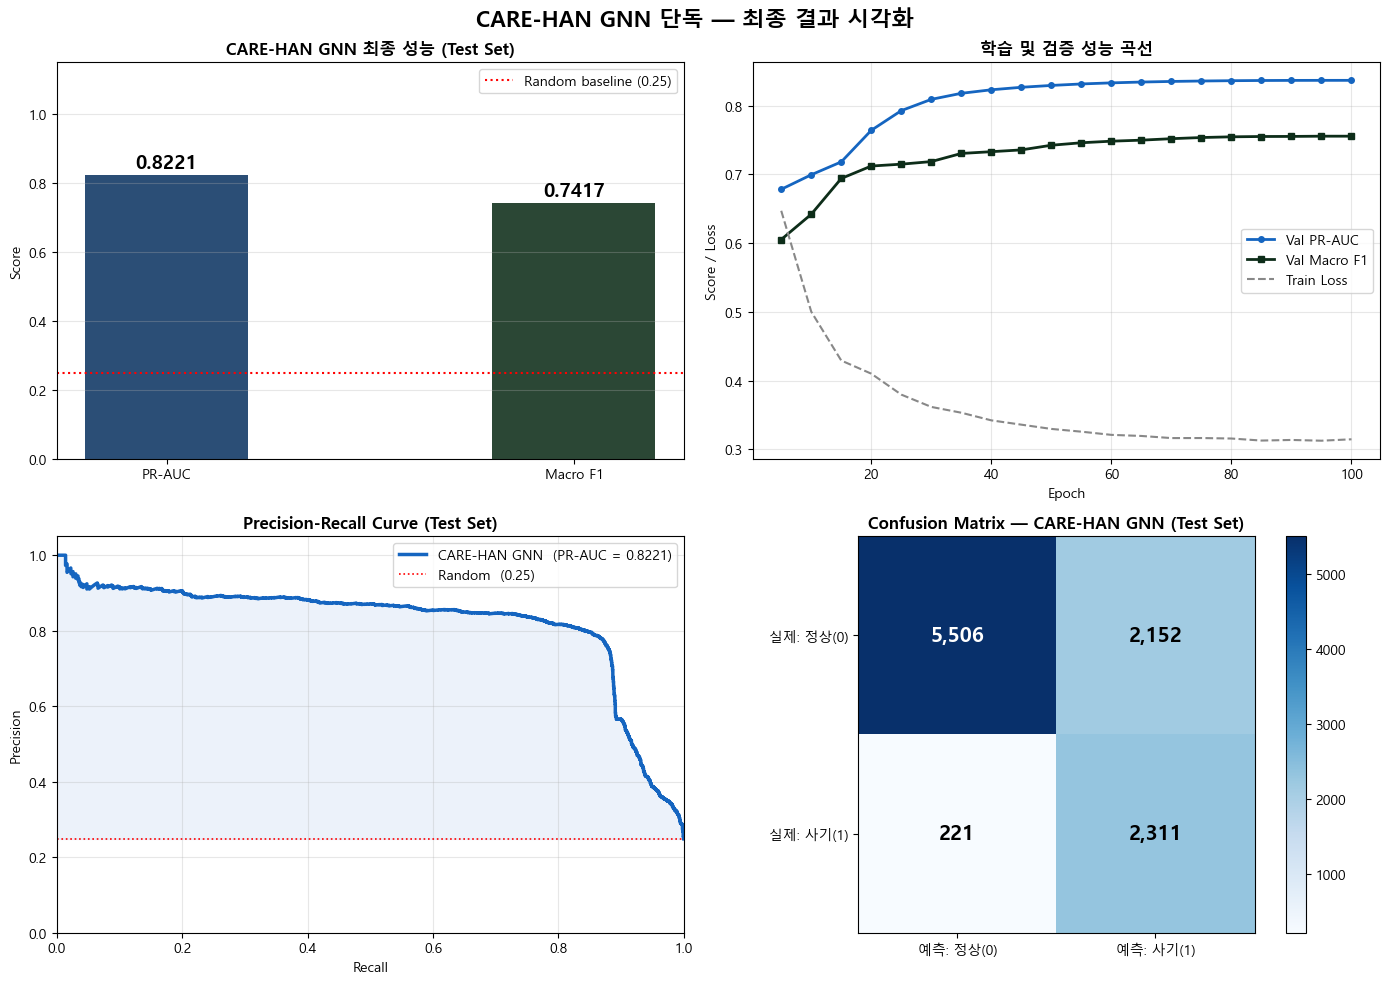

✅ CARE-HAN GNN 단독 시각화 저장 완료: care_han_gnn_results.png


In [14]:
# [13-viz] CARE-HAN GNN 단독 결과 시각화
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix
import platform

_font = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'DejaVu Sans')
plt.rcParams['font.family'] = _font
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CARE-HAN GNN 단독 — 최종 결과 시각화', fontsize=16, fontweight='bold')

# ── (1) 최종 성능 요약 ──────────────────────────────────────────────
ax = axes[0, 0]
metrics    = ['PR-AUC', 'Macro F1']
values     = [gnn_prauc, gnn_f1]
bar_colors = ["#0D3563", "#0D2D19"]
brs = ax.bar(metrics, values, color=bar_colors, alpha=0.88, width=0.4)
for b, v in zip(brs, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('CARE-HAN GNN 최종 성능 (Test Set)', fontweight='bold')
ax.axhline(y_test_np.mean(), color='red', linestyle=':', lw=1.5,
           label=f'Random baseline ({y_test_np.mean():.2f})')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# ── (2) 학습 곡선 ───────────────────────────────────────────────────
ax = axes[0, 1]
ep_axis = list(range(5, 5 * len(history['val_prauc']) + 1, 5))
ax.plot(ep_axis, history['val_prauc'], color='#1565C0', lw=2, marker='o', ms=4,
        label='Val PR-AUC')
ax.plot(ep_axis, history['val_f1'],    color='#0D2D19', lw=2, marker='s', ms=4,
        label='Val Macro F1')
ax.plot(ep_axis, history['train_loss'], color='#888', lw=1.5, linestyle='--',
        label='Train Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score / Loss')
ax.set_title('학습 및 검증 성능 곡선', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── (3) Precision-Recall Curve ──────────────────────────────────────
ax = axes[1, 0]
prec_g, rec_g, _ = precision_recall_curve(y_test_np, probs_gnn[idx_test])
ax.plot(rec_g, prec_g, color='#1565C0', lw=2.5,
        label=f'CARE-HAN GNN  (PR-AUC = {gnn_prauc:.4f})')
ax.axhline(y_test_np.mean(), color='red', linestyle=':', lw=1.2,
           label=f'Random  ({y_test_np.mean():.2f})')
ax.fill_between(rec_g, prec_g, y_test_np.mean(), alpha=0.08, color='#1565C0')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Test Set)', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── (4) 혼동 행렬 ───────────────────────────────────────────────────
ax = axes[1, 1]
cm_g = confusion_matrix(y_test_np, preds_gnn[idx_test])
im = ax.imshow(cm_g, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['예측: 정상(0)', '예측: 사기(1)'], fontsize=10)
ax.set_yticklabels(['실제: 정상(0)', '실제: 사기(1)'], fontsize=10)
ax.set_title('Confusion Matrix — CARE-HAN GNN (Test Set)', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_g[i,j]:,}', ha='center', va='center',
                fontsize=15, fontweight='bold',
                color='white' if cm_g[i,j] > cm_g.max() / 2 else 'black')

plt.tight_layout()
plt.savefig('care_han_gnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ CARE-HAN GNN 단독 시각화 저장 완료: care_han_gnn_results.png')

In [15]:
# [14] CatBoost 하이브리드 (GNN 임베딩 128 + 원시 피처 78 = 206-dim)
cb_prauc = None
cb_f1    = None

if not CATBOOST_AVAILABLE:
    print('CatBoost 미설치 — 셀을 건너뜁니다.')
    print('   pip install catboost 후 재실행하세요.')
else:
    # 206-dim 하이브리드 피처 행렬
    X_hybrid = np.hstack([emb_all, x_rev])  # (N_R, 206)

    X_tr_cb = X_hybrid[idx_train]
    y_tr_cb = labels[idx_train]
    X_va_cb = X_hybrid[idx_val]
    y_va_cb = labels[idx_val]
    X_te_cb = X_hybrid[idx_test]
    y_te_cb = labels[idx_test]

    hybrid_dim = X_hybrid.shape[1]
    print(f'CatBoost 입력 차원: {hybrid_dim}  (GNN 128 + 원시 78)')

    cb_model = CatBoostClassifier(
        iterations=CFG['cb_iterations'],
        depth=CFG['cb_depth'],
        learning_rate=CFG['cb_lr'],
        loss_function='Logloss',
        eval_metric='AUC',
        class_weights={0: 1, 1: int(w_pos)},
        random_seed=CFG['random_state'],
        verbose=100,
        early_stopping_rounds=50,
    )
    cb_model.fit(
        X_tr_cb, y_tr_cb,
        eval_set=(X_va_cb, y_va_cb),
        use_best_model=True
    )

    cb_model_path = os.path.join(BASE_DIR, 'best_catboost.cbm')
    cb_model.save_model(cb_model_path)

    probs_cb = cb_model.predict_proba(X_te_cb)[:, 1]
    preds_cb = cb_model.predict(X_te_cb)
    cb_prauc = float(average_precision_score(y_te_cb, probs_cb))
    cb_f1    = float(f1_score(y_te_cb, preds_cb, average='macro', zero_division=0))

    print(f'\nCatBoost 저장: {cb_model_path}')
    print(f'[하이브리드]  Test PR-AUC: {cb_prauc:.4f}  Macro-F1: {cb_f1:.4f}')

CatBoost 입력 차원: 206  (GNN 128 + 원시 78)
0:	test: 0.9285474	best: 0.9285474 (0)	total: 284ms	remaining: 4m 43s
100:	test: 0.9720867	best: 0.9720867 (100)	total: 13.3s	remaining: 1m 58s
200:	test: 0.9761444	best: 0.9761444 (200)	total: 19.3s	remaining: 1m 16s
300:	test: 0.9787338	best: 0.9787338 (300)	total: 25.4s	remaining: 59s
400:	test: 0.9798521	best: 0.9798521 (400)	total: 31.5s	remaining: 47s
500:	test: 0.9806190	best: 0.9806190 (500)	total: 36.9s	remaining: 36.8s
600:	test: 0.9813402	best: 0.9813418 (598)	total: 42.3s	remaining: 28.1s
700:	test: 0.9814989	best: 0.9815521 (680)	total: 47.6s	remaining: 20.3s
800:	test: 0.9819062	best: 0.9819243 (796)	total: 52.9s	remaining: 13.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9820599774
bestIteration = 844

Shrink model to first 845 iterations.

CatBoost 저장: c:\Users\bella\Desktop\대학\CODE\GNN 학술제\best_catboost.cbm
[하이브리드]  Test PR-AUC: 0.9279  Macro-F1: 0.9136


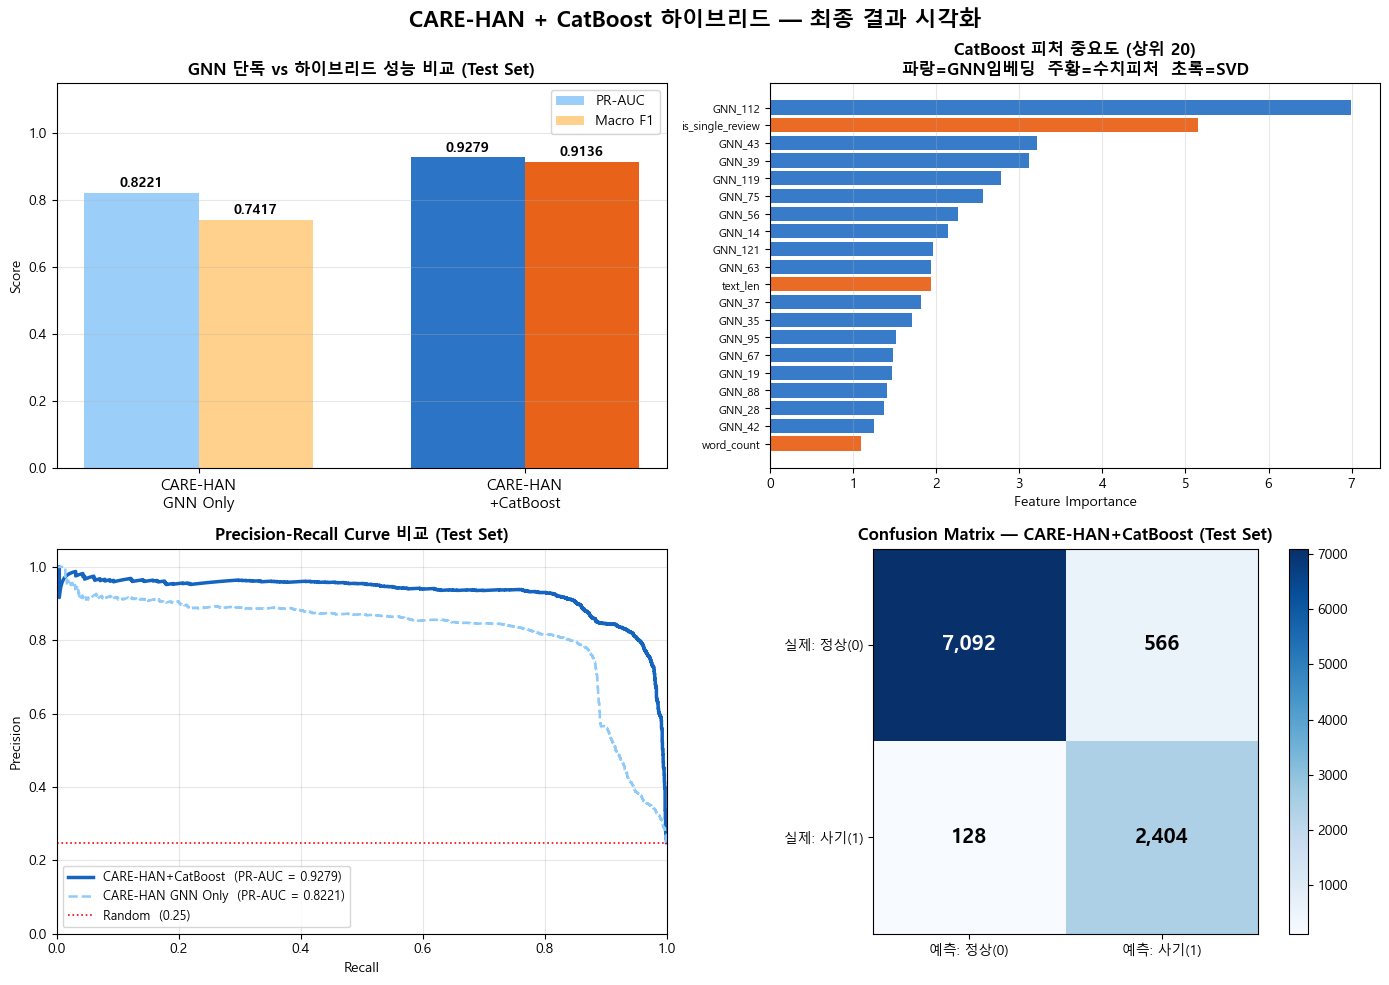

✅ CARE-HAN+CatBoost 하이브리드 시각화 저장 완료: care_han_hybrid_results.png


In [16]:
# [14-viz] CARE-HAN + CatBoost 하이브리드 결과 시각화
if not CATBOOST_AVAILABLE or cb_prauc is None:
    print('CatBoost 미실행 — 시각화를 건너뜁니다.')
else:
    import matplotlib.pyplot as plt
    from sklearn.metrics import precision_recall_curve, confusion_matrix
    import platform

    _font = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'DejaVu Sans')
    plt.rcParams['font.family'] = _font
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('CARE-HAN + CatBoost 하이브리드 — 최종 결과 시각화', fontsize=16, fontweight='bold')

    # ── (1) GNN 단독 vs 하이브리드 성능 비교 ─────────────────────────
    ax = axes[0, 0]
    x = np.arange(2)
    w = 0.35
    b1 = ax.bar(x - w/2, [gnn_prauc, cb_prauc], w, label='PR-AUC',
                color=['#90CAF9', '#1565C0'], alpha=0.9)
    b2 = ax.bar(x + w/2, [gnn_f1,    cb_f1],   w, label='Macro F1',
                color=['#FFCC80', '#E65100'], alpha=0.9)
    for b in list(b1) + list(b2):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['CARE-HAN\nGNN Only', 'CARE-HAN\n+CatBoost'], fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title('GNN 단독 vs 하이브리드 성능 비교 (Test Set)', fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # ── (2) CatBoost 피처 중요도 (상위 20) ───────────────────────────
    ax = axes[0, 1]
    feat_names_hybrid = (
        [f'GNN_{i}' for i in range(CFG['hidden_dim'])] +
        FEAT_COLS +
        [f'SVD_{i}' for i in range(CFG['svd_dim'])]
    )
    fi      = cb_model.get_feature_importance()
    top_n   = 20
    top_idx = np.argsort(fi)[::-1][:top_n]
    top_fi  = fi[top_idx]
    top_lbl = [feat_names_hybrid[i] for i in top_idx]
    fi_colors = ['#1565C0' if l.startswith('GNN') else
                 '#43A047' if l.startswith('SVD') else '#E65100'
                 for l in top_lbl]
    ax.barh(range(top_n), top_fi[::-1], color=fi_colors[::-1], alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_lbl[::-1], fontsize=8)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'CatBoost 피처 중요도 (상위 {top_n})\n파랑=GNN임베딩  주황=수치피처  초록=SVD',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # ── (3) PR Curve: GNN 단독 vs 하이브리드 ─────────────────────────
    ax = axes[1, 0]
    _prec_g, _rec_g, _ = precision_recall_curve(y_test_np, probs_gnn[idx_test])
    _prec_c, _rec_c, _ = precision_recall_curve(y_te_cb, probs_cb)
    ax.plot(_rec_c, _prec_c, color='#1565C0', lw=2.5,
            label=f'CARE-HAN+CatBoost  (PR-AUC = {cb_prauc:.4f})')
    ax.plot(_rec_g, _prec_g, color='#90CAF9', lw=1.8, linestyle='--',
            label=f'CARE-HAN GNN Only  (PR-AUC = {gnn_prauc:.4f})')
    ax.axhline(y_test_np.mean(), color='red', linestyle=':', lw=1.2,
               label=f'Random  ({y_test_np.mean():.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve 비교 (Test Set)', fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── (4) 혼동 행렬 (하이브리드) ──────────────────────────────────
    ax = axes[1, 1]
    cm_c = confusion_matrix(y_te_cb, preds_cb)
    im = ax.imshow(cm_c, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['예측: 정상(0)', '예측: 사기(1)'], fontsize=10)
    ax.set_yticklabels(['실제: 정상(0)', '실제: 사기(1)'], fontsize=10)
    ax.set_title('Confusion Matrix — CARE-HAN+CatBoost (Test Set)', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_c[i,j]:,}', ha='center', va='center',
                    fontsize=15, fontweight='bold',
                    color='white' if cm_c[i,j] > cm_c.max() / 2 else 'black')

    plt.tight_layout()
    plt.savefig('care_han_hybrid_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ CARE-HAN+CatBoost 하이브리드 시각화 저장 완료: care_han_hybrid_results.png')

결과 저장: c:\Users\bella\Desktop\대학\CODE\GNN 학술제\results_06.json
전체 모델 수치 (참고)
모델                                   PR-AUC   Macro-F1
----------------------------------------------------------------
04. ReviewRGCN (baseline)            0.6041     0.5896
05. PC-GNN (예선)                      0.8634     0.7701
06. CARE-HAN GNN Only                0.8221     0.7417
06+. CARE-HAN+CatBoost (최종)          0.9279     0.9136

  모델 선택 근거 — CARE-HAN + CatBoost

  ■ 왜 PC-GNN이 아닌 CARE-HAN인가?
    PC-GNN은 Review 노드 단일 유형의 동질 그래프(homogeneous graph)로,
    사용자·식당의 구조적 컨텍스트를 직접 활용할 수 없습니다.
    YelpZip은 'Review 작성자(User)'와 '평가 대상(Restaurant)'이라는
    이질적 엔티티가 존재하는 이종 정보 네트워크(HIN)입니다.

    CARE-HAN은 3종 노드(Review 78-dim, User 12-dim, Restaurant 6-dim)와
    4종 이질 엣지를 동시에 모델링하며 두 가지 핵심 메커니즘을 제공합니다:
      ① Trust-Aware CARE 게이트: 이웃 노드의 신뢰도를 메시지 가중치로 반영
         → 위장 정상 리뷰가 사기 노드에 미치는 영향 억제
      ② Semantic Attention: R-Sim-R / U-writes-R / P-about-R 3관계의
         기여도를 동적으로 학습 → 관계별 중요도 자동 포착

  ■ 왜 CatBoost를 추가했는가?

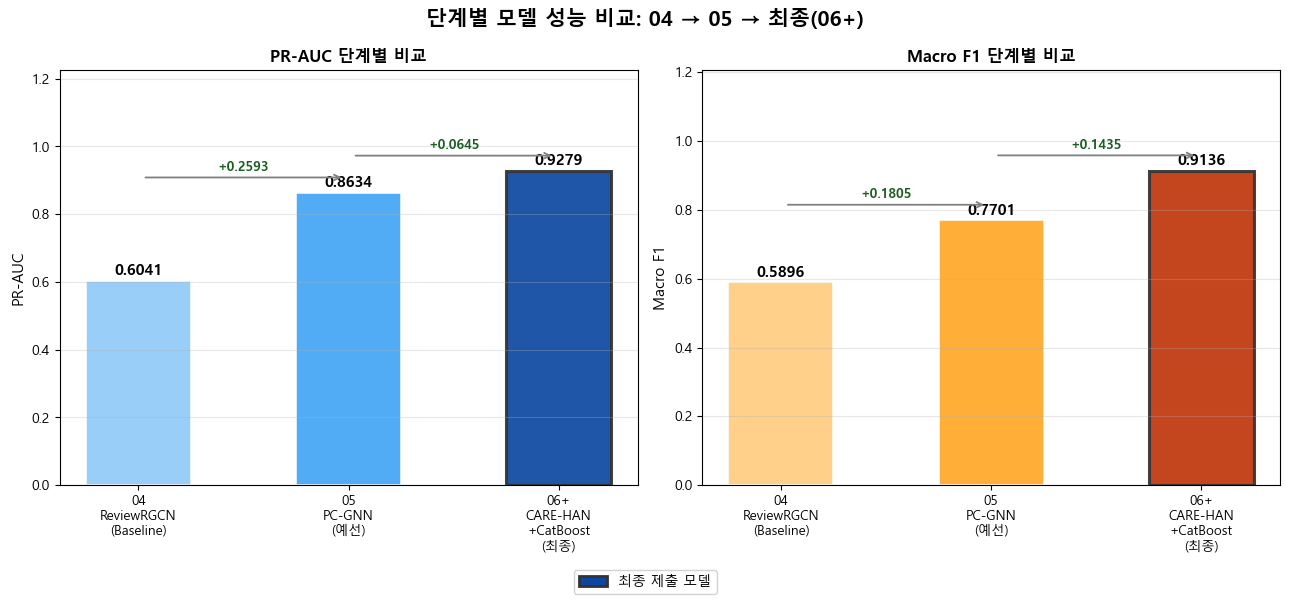

✅ 3-way 비교 시각화 저장 완료: model_comparison.png

[최종 모델: CARE-HAN+CatBoost 분류 리포트]
              precision    recall  f1-score   support

      Normal     0.9823    0.9261    0.9534      7658
       Fraud     0.8094    0.9494    0.8739      2532

    accuracy                         0.9319     10190
   macro avg     0.8958    0.9378    0.9136     10190
weighted avg     0.9393    0.9319    0.9336     10190



In [17]:
# [15] 최종 성능 리포트 및 3-way 비교 시각화

# 04/05 결과 로드 (존재 시)
def _load(fname):
    fpath = os.path.join(BASE_DIR, fname)
    if os.path.exists(fpath):
        with open(fpath, encoding='utf-8') as f:
            return _json.load(f)
    return None

res_04 = _load('results_04.json')
res_05 = _load('results_05.json')

# 06 결과 저장
results_06 = {
    'model'         : 'CARE-HAN + CatBoost',
    'gnn_only'      : {'pr_auc': float(gnn_prauc), 'macro_f1': float(gnn_f1)},
    'hybrid'        : {'pr_auc': cb_prauc,          'macro_f1': cb_f1},
    'best_val_prauc': float(best_val_prauc),
}
save_path = os.path.join(BASE_DIR, 'results_06.json')
with open(save_path, 'w', encoding='utf-8') as f:
    _json.dump(results_06, f, ensure_ascii=False, indent=2)
print(f'결과 저장: {save_path}')

# ─── 전체 수치 텍스트 테이블 (참고용) ────────────────────────────────
SEP = '=' * 64
print(SEP)
print('전체 모델 수치 (참고)')
print(SEP)
print(f'{"모델":<34} {"PR-AUC":>8} {"Macro-F1":>10}')
print('-' * 64)

if res_04:
    pr04 = res_04.get('pr_auc', res_04.get('baseline', {}).get('pr_auc', None))
    f104 = res_04.get('macro_f1', res_04.get('baseline', {}).get('macro_f1', None))
    print(f'{"04. ReviewRGCN (baseline)":<34} {float(pr04):>8.4f} {float(f104):>10.4f}')
else:
    print(f'{"04. ReviewRGCN (baseline)":<34} {"미실행":>8} {"미실행":>10}')

if res_05:
    pr05 = res_05.get('pr_auc', res_05.get('baseline', {}).get('pr_auc', None))
    f105 = res_05.get('macro_f1', res_05.get('baseline', {}).get('macro_f1', None))
    print(f'{"05. PC-GNN (예선)":<34} {float(pr05):>8.4f} {float(f105):>10.4f}')
else:
    print(f'{"05. PC-GNN (예선)":<34} {"미실행":>8} {"미실행":>10}')

print(f'{"06. CARE-HAN GNN Only":<34} {gnn_prauc:>8.4f} {gnn_f1:>10.4f}')
if cb_prauc is not None:
    print(f'{"06+. CARE-HAN+CatBoost (최종)":<34} {cb_prauc:>8.4f} {cb_f1:>10.4f}')
print(SEP)

# ─── 설계 근거 출력 ────────────────────────────────────────────────
W = 64
print()
print('=' * W)
print('  모델 선택 근거 — CARE-HAN + CatBoost')
print('=' * W)
print("""
  ■ 왜 PC-GNN이 아닌 CARE-HAN인가?
    PC-GNN은 Review 노드 단일 유형의 동질 그래프(homogeneous graph)로,
    사용자·식당의 구조적 컨텍스트를 직접 활용할 수 없습니다.
    YelpZip은 'Review 작성자(User)'와 '평가 대상(Restaurant)'이라는
    이질적 엔티티가 존재하는 이종 정보 네트워크(HIN)입니다.

    CARE-HAN은 3종 노드(Review 78-dim, User 12-dim, Restaurant 6-dim)와
    4종 이질 엣지를 동시에 모델링하며 두 가지 핵심 메커니즘을 제공합니다:
      ① Trust-Aware CARE 게이트: 이웃 노드의 신뢰도를 메시지 가중치로 반영
         → 위장 정상 리뷰가 사기 노드에 미치는 영향 억제
      ② Semantic Attention: R-Sim-R / U-writes-R / P-about-R 3관계의
         기여도를 동적으로 학습 → 관계별 중요도 자동 포착

  ■ 왜 CatBoost를 추가했는가?
    GNN 임베딩(128차원)은 그래프 구조 정보를 압축하지만,
    개별 행동 패턴(버스트, 평점 편차, cold-start 등)은 원시 피처(78차원)에
    더 직접적으로 담겨 있습니다.

    CatBoost 하이브리드(206차원)는 두 정보원을 결합하여:
      ① 구조 신호(GNN 임베딩): 조직적 공모 네트워크 패턴
      ② 행동 신호(원시 피처): 개별 사기꾼의 통계적 이상 패턴
    을 동시에 포착 — 어느 한쪽만으로는 놓치는 사기를 상호 보완합니다.
""")
print('=' * W)

# ─── 3-way 비교 시각화 (04 → 05 → 06+) ───────────────────────────
# 06 GNN Only는 제외: 최종 제출 모델(06+)로의 단계적 개선만 표시
model_rows = []

if res_04 and res_04.get('pr_auc') is not None:
    model_rows.append(('04\nReviewRGCN\n(Baseline)',
                        float(res_04['pr_auc']), float(res_04['macro_f1'])))

if res_05 and res_05.get('pr_auc') is not None:
    model_rows.append(('05\nPC-GNN\n(예선)',
                        float(res_05['pr_auc']), float(res_05['macro_f1'])))

if cb_prauc is not None:
    model_rows.append(('06+\nCARE-HAN\n+CatBoost\n(최종)',
                        cb_prauc, cb_f1))
elif gnn_prauc:
    model_rows.append(('06\nCARE-HAN\nGNN Only',
                        gnn_prauc, gnn_f1))

if model_rows:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import platform
    _font = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'DejaVu Sans')
    plt.rcParams['font.family'] = _font
    plt.rcParams['axes.unicode_minus'] = False

    n       = len(model_rows)
    lbl_x   = [r[0] for r in model_rows]
    pr_vals = [r[1] for r in model_rows]
    f1_vals = [r[2] for r in model_rows]
    x       = np.arange(n)

    # 단계별로 색이 진해지는 팔레트 (마지막=최종 모델 강조)
    pr_palette = ['#90CAF9', '#42A5F5', '#0D47A1'][:n]
    f1_palette = ['#FFCC80', '#FFA726', '#BF360C'][:n]

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle('단계별 모델 성능 비교: 04 → 05 → 최종(06+)',
                 fontsize=15, fontweight='bold')

    for ax, vals, colors, title, ylabel in [
        (axes[0], pr_vals, pr_palette, 'PR-AUC 단계별 비교',   'PR-AUC'),
        (axes[1], f1_vals, f1_palette, 'Macro F1 단계별 비교', 'Macro F1'),
    ]:
        brs = ax.bar(x, vals, color=colors, alpha=0.92, width=0.5,
                     edgecolor='white', linewidth=1.2)

        # 마지막 바(최종 모델) 테두리 강조
        brs[-1].set_edgecolor('#333')
        brs[-1].set_linewidth(2.2)

        for b, v in zip(brs, vals):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                    f'{v:.4f}', ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(lbl_x, fontsize=9.5)
        ax.set_ylim(0, max(vals) * 1.32)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.grid(axis='y', alpha=0.3)

        # 단계간 화살표 + 개선폭
        for i in range(1, n):
            delta = vals[i] - vals[i - 1]
            sign  = '+' if delta >= 0 else ''
            col   = '#1B5E20' if delta >= 0 else '#B71C1C'
            top_y = max(vals[i], vals[i - 1])
            ax.annotate('',
                        xy=(x[i] - 0.02, top_y + 0.045),
                        xytext=(x[i-1] + 0.02, top_y + 0.045),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1.3))
            ax.text((x[i] + x[i-1]) / 2, top_y + 0.065,
                    f'{sign}{delta:.4f}', ha='center', fontsize=9.5,
                    color=col, fontweight='bold')

    # 범례: 최종 모델 표시
    final_patch = mpatches.Patch(facecolor=pr_palette[-1], edgecolor='#333',
                                 linewidth=2, label='최종 제출 모델')
    fig.legend(handles=[final_patch], loc='lower center', ncol=1,
               fontsize=10, framealpha=0.85)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    cmp_path = os.path.join(BASE_DIR, 'model_comparison.png')
    plt.savefig(cmp_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 3-way 비교 시각화 저장 완료: model_comparison.png')

# ─── 최종 모델 분류 리포트 ─────────────────────────────────────────
from sklearn.metrics import classification_report
if cb_prauc is not None:
    print('\n[최종 모델: CARE-HAN+CatBoost 분류 리포트]')
    print(classification_report(y_te_cb, preds_cb,
                                target_names=['Normal', 'Fraud'], digits=4))
else:
    print('\n[최종 모델: CARE-HAN GNN Only 분류 리포트]')
    print(classification_report(y_test_np, preds_gnn[idx_test],
                                target_names=['Normal', 'Fraud'], digits=4))

  과적합 최종 점검 — Train / Val / Test 갭 분석

[CARE-HAN GNN  (전이적 학습)]
  Split     PR-AUC   Macro F1
  Train     0.8886     0.8689
  Val       0.8369     0.7557
  Test      0.8221     0.7417
  Train-Test 갭: +0.0665  |  Val-Test 갭: +0.0148

[CatBoost 하이브리드  (귀납적 학습)]
  Split     PR-AUC   Macro F1
  Train     0.9992     0.9929
  Val       0.9375     0.9228
  Test      0.9279     0.9136
  Train-Test 갭: +0.0713  |  Val-Test 갭: +0.0096

  자동 판정  (기준: Train-Test 갭 < 0.05, Val-Test 갭 < 0.05)
⚠️  CARE-HAN GNN: Train-Test 갭 0.0665 > 0.05 → 경미한 과적합 주의
⚠️  CatBoost 하이브리드: Train-Test 갭 0.0713 > 0.05 → 경미한 과적합 주의

[GNN 전이적 학습 유의사항]
  - 학습 시 val/test 노드도 메시지 패싱에 참여 (라벨은 손실에서 제외)
  - Train PR-AUC가 Val/Test보다 낮거나 유사한 것은 정상 (전이적 특성)
  - 핵심 지표: Val-Test 갭이 작을수록 일반화 양호



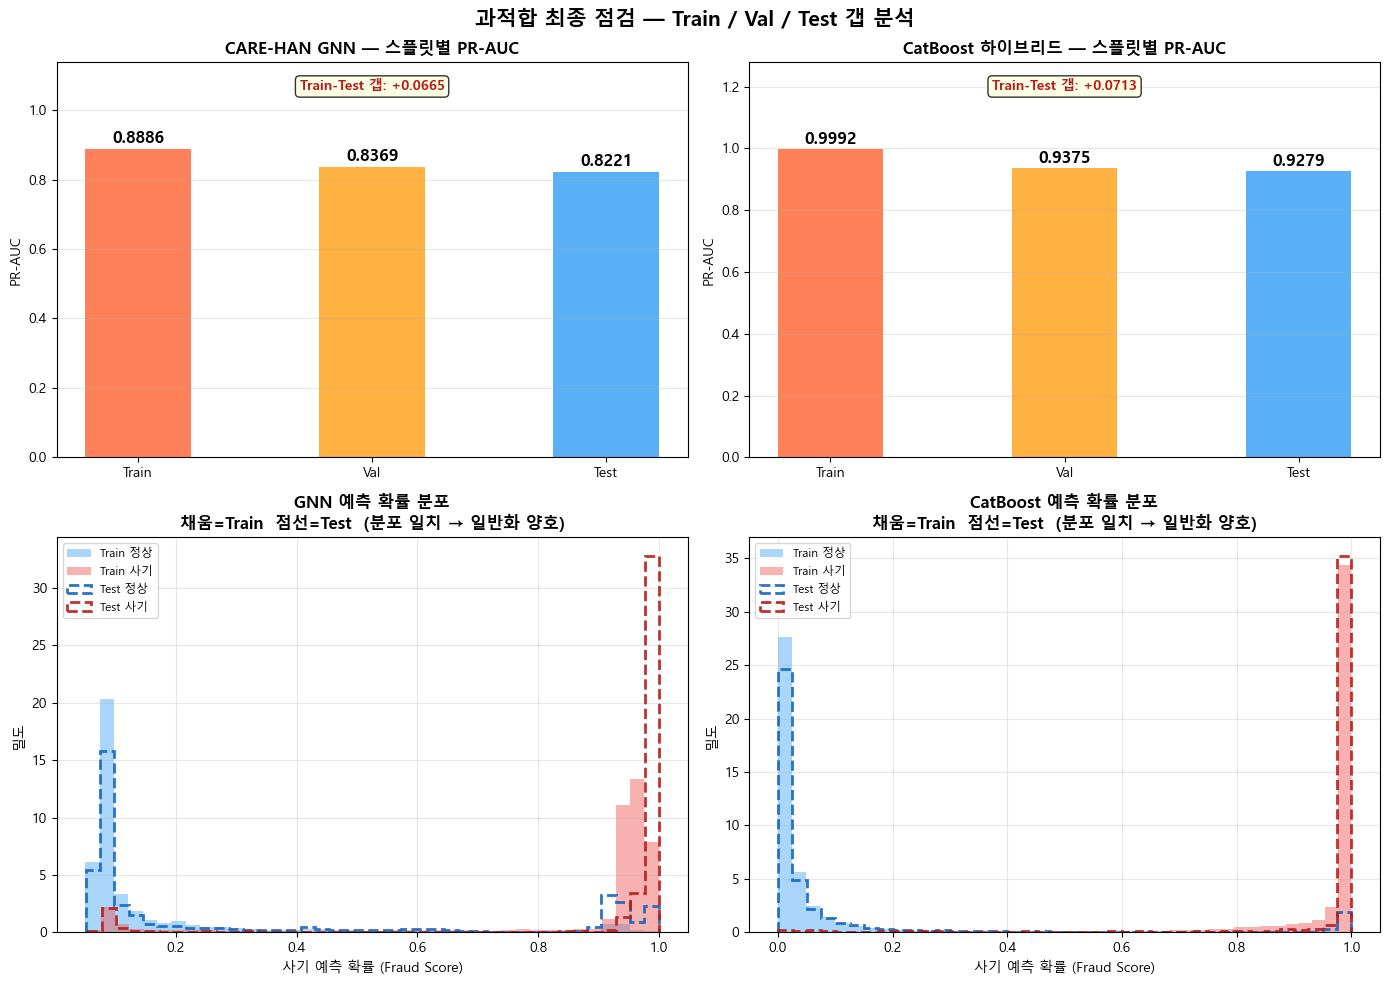

✅ 과적합 점검 시각화 저장 완료: overfit_check.png


: 

In [ ]:
# [16] 과적합 최종 점검 — Train / Val / Test 갭 분석
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, f1_score
import platform

_font = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'DejaVu Sans')
plt.rcParams['font.family'] = _font
plt.rcParams['axes.unicode_minus'] = False

SEP = '=' * 66

# ─── GNN 스플릿별 성능 계산 ─────────────────────────────────────────
gnn_tr_pr = average_precision_score(labels[idx_train], probs_gnn[idx_train])
gnn_va_pr = average_precision_score(labels[idx_val],   probs_gnn[idx_val])
gnn_te_pr = gnn_prauc
gnn_tr_f1 = f1_score(labels[idx_train], preds_gnn[idx_train], average='macro')
gnn_va_f1 = f1_score(labels[idx_val],   preds_gnn[idx_val],   average='macro')
gnn_te_f1 = gnn_f1
gap_gnn_tr_te = gnn_tr_pr - gnn_te_pr
gap_gnn_va_te = gnn_va_pr - gnn_te_pr

# ─── CatBoost 스플릿별 성능 계산 ────────────────────────────────────
cb_ok = CATBOOST_AVAILABLE and cb_prauc is not None
if cb_ok:
    cb_tr_prob = cb_model.predict_proba(X_tr_cb)[:, 1]
    cb_va_prob = cb_model.predict_proba(X_va_cb)[:, 1]
    cb_tr_pr   = average_precision_score(y_tr_cb, cb_tr_prob)
    cb_va_pr   = average_precision_score(y_va_cb, cb_va_prob)
    cb_te_pr   = cb_prauc
    cb_tr_f1   = f1_score(y_tr_cb, (cb_tr_prob > 0.5).astype(int), average='macro')
    cb_va_f1   = f1_score(y_va_cb, (cb_va_prob > 0.5).astype(int), average='macro')
    cb_te_f1   = cb_f1
    gap_cb_tr_te = cb_tr_pr - cb_te_pr
    gap_cb_va_te = cb_va_pr - cb_te_pr

# ─── 텍스트 리포트 ─────────────────────────────────────────────────
print(SEP)
print('  과적합 최종 점검 — Train / Val / Test 갭 분석')
print(SEP)

print('\n[CARE-HAN GNN  (전이적 학습)]')
print(f'  {"Split":<6} {"PR-AUC":>9} {"Macro F1":>10}')
print(f'  {"Train":<6} {gnn_tr_pr:>9.4f} {gnn_tr_f1:>10.4f}')
print(f'  {"Val":<6} {gnn_va_pr:>9.4f} {gnn_va_f1:>10.4f}')
print(f'  {"Test":<6} {gnn_te_pr:>9.4f} {gnn_te_f1:>10.4f}')
print(f'  Train-Test 갭: {gap_gnn_tr_te:+.4f}  |  Val-Test 갭: {gap_gnn_va_te:+.4f}')

if cb_ok:
    print('\n[CatBoost 하이브리드  (귀납적 학습)]')
    print(f'  {"Split":<6} {"PR-AUC":>9} {"Macro F1":>10}')
    print(f'  {"Train":<6} {cb_tr_pr:>9.4f} {cb_tr_f1:>10.4f}')
    print(f'  {"Val":<6} {cb_va_pr:>9.4f} {cb_va_f1:>10.4f}')
    print(f'  {"Test":<6} {cb_te_pr:>9.4f} {cb_te_f1:>10.4f}')
    print(f'  Train-Test 갭: {gap_cb_tr_te:+.4f}  |  Val-Test 갭: {gap_cb_va_te:+.4f}')

# ─── 자동 판정 ──────────────────────────────────────────────────────
def _verdict(gap_tr_te, gap_va_te, name):
    issues = []
    if gap_tr_te > 0.10:
        issues.append(f'Train-Test 갭 {gap_tr_te:.4f} > 0.10 → 과적합 의심')
    elif gap_tr_te > 0.05:
        issues.append(f'Train-Test 갭 {gap_tr_te:.4f} > 0.05 → 경미한 과적합 주의')
    if abs(gap_va_te) > 0.05:
        issues.append(f'Val-Test 갭 {gap_va_te:.4f} > 0.05 → 분포 불일치 주의')
    if issues:
        return f'⚠️  {name}: ' + ' | '.join(issues)
    return (f'✅ {name}: 과적합 없음'
            f'  (Train-Test {gap_tr_te:+.4f} / Val-Test {gap_va_te:+.4f})')

print()
print(SEP)
print('  자동 판정  (기준: Train-Test 갭 < 0.05, Val-Test 갭 < 0.05)')
print(SEP)
print(_verdict(gap_gnn_tr_te, gap_gnn_va_te, 'CARE-HAN GNN'))
if cb_ok:
    print(_verdict(gap_cb_tr_te, gap_cb_va_te, 'CatBoost 하이브리드'))

print(f"""
[GNN 전이적 학습 유의사항]
  - 학습 시 val/test 노드도 메시지 패싱에 참여 (라벨은 손실에서 제외)
  - Train PR-AUC가 Val/Test보다 낮거나 유사한 것은 정상 (전이적 특성)
  - 핵심 지표: Val-Test 갭이 작을수록 일반화 양호
""")
print(SEP)

# ─── 시각화 (2×2) ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('과적합 최종 점검 — Train / Val / Test 갭 분석', fontsize=15, fontweight='bold')

split_labels = ['Train', 'Val', 'Test']
split_colors = ['#FF7043', '#FFA726', '#42A5F5']

# ── (1) GNN PR-AUC 스플릿 비교 ──────────────────────────────────────
ax = axes[0, 0]
gnn_pr_vals = [gnn_tr_pr, gnn_va_pr, gnn_te_pr]
brs = ax.bar(split_labels, gnn_pr_vals, color=split_colors, alpha=0.88, width=0.45)
for b, v in zip(brs, gnn_pr_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004,
            f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(gnn_pr_vals) * 1.28)
ax.set_ylabel('PR-AUC')
ax.set_title('CARE-HAN GNN — 스플릿별 PR-AUC', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
col_g = '#B71C1C' if abs(gap_gnn_tr_te) > 0.05 else '#1B5E20'
ax.text(0.5, 0.93, f'Train-Test 갭: {gap_gnn_tr_te:+.4f}',
        transform=ax.transAxes, ha='center', fontsize=10,
        color=col_g, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── (2) CatBoost PR-AUC 스플릿 비교 (없으면 GNN F1) ─────────────────
ax = axes[0, 1]
if cb_ok:
    cb_pr_vals = [cb_tr_pr, cb_va_pr, cb_te_pr]
    brs = ax.bar(split_labels, cb_pr_vals, color=split_colors, alpha=0.88, width=0.45)
    for b, v in zip(brs, cb_pr_vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004,
                f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(cb_pr_vals) * 1.28)
    ax.set_ylabel('PR-AUC')
    ax.set_title('CatBoost 하이브리드 — 스플릿별 PR-AUC', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    col_c = '#B71C1C' if abs(gap_cb_tr_te) > 0.05 else '#1B5E20'
    ax.text(0.5, 0.93, f'Train-Test 갭: {gap_cb_tr_te:+.4f}',
            transform=ax.transAxes, ha='center', fontsize=10,
            color=col_c, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
else:
    gnn_f1_vals = [gnn_tr_f1, gnn_va_f1, gnn_te_f1]
    brs = ax.bar(split_labels, gnn_f1_vals, color=split_colors, alpha=0.88, width=0.45)
    for b, v in zip(brs, gnn_f1_vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004,
                f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(gnn_f1_vals) * 1.28)
    ax.set_ylabel('Macro F1')
    ax.set_title('CARE-HAN GNN — 스플릿별 Macro F1', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# ── (3) GNN 예측 확률 분포 (Train vs Test, 클래스별) ─────────────────
ax = axes[1, 0]
bins = 40
# Train — 채워진 히스토그램
ax.hist(probs_gnn[idx_train][labels[idx_train] == 0], bins=bins, alpha=0.45,
        color='#42A5F5', label='Train 정상', density=True)
ax.hist(probs_gnn[idx_train][labels[idx_train] == 1], bins=bins, alpha=0.45,
        color='#EF5350', label='Train 사기',  density=True)
# Test — 윤곽선만 (점선)
ax.hist(probs_gnn[idx_test][labels[idx_test] == 0], bins=bins, alpha=0.9,
        color='#1565C0', label='Test 정상',  density=True,
        histtype='step', linewidth=2, linestyle='--')
ax.hist(probs_gnn[idx_test][labels[idx_test] == 1], bins=bins, alpha=0.9,
        color='#B71C1C', label='Test 사기',   density=True,
        histtype='step', linewidth=2, linestyle='--')
ax.set_xlabel('사기 예측 확률 (Fraud Score)')
ax.set_ylabel('밀도')
ax.set_title('GNN 예측 확률 분포\n채움=Train  점선=Test  (분포 일치 → 일반화 양호)',
             fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3)

# ── (4) CatBoost 예측 확률 분포 또는 학습 곡선 ──────────────────────
ax = axes[1, 1]
if cb_ok:
    ax.hist(cb_tr_prob[y_tr_cb == 0], bins=bins, alpha=0.45,
            color='#42A5F5', label='Train 정상', density=True)
    ax.hist(cb_tr_prob[y_tr_cb == 1], bins=bins, alpha=0.45,
            color='#EF5350', label='Train 사기',  density=True)
    ax.hist(probs_cb[y_te_cb == 0], bins=bins, alpha=0.9,
            color='#1565C0', label='Test 정상',  density=True,
            histtype='step', linewidth=2, linestyle='--')
    ax.hist(probs_cb[y_te_cb == 1], bins=bins, alpha=0.9,
            color='#B71C1C', label='Test 사기',   density=True,
            histtype='step', linewidth=2, linestyle='--')
    ax.set_xlabel('사기 예측 확률 (Fraud Score)')
    ax.set_ylabel('밀도')
    ax.set_title('CatBoost 예측 확률 분포\n채움=Train  점선=Test  (분포 일치 → 일반화 양호)',
                 fontweight='bold')
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.3)
else:
    # 학습 곡선으로 대체
    ep_axis = list(range(5, 5 * len(history['val_prauc']) + 1, 5))
    ax.plot(ep_axis, history['val_prauc'], color='#42A5F5', lw=2.2, marker='o', ms=4,
            label='Val PR-AUC')
    ax.plot(ep_axis, history['val_f1'],    color='#E65100', lw=2.2, marker='s', ms=4,
            label='Val Macro F1')
    ax.axvline(ep_axis[np.argmax(history['val_prauc'])], color='gray',
               linestyle=':', lw=1.5, label='Best epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('GNN 검증 성능 곡선\n(수렴 확인)', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfit_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 과적합 점검 시각화 저장 완료: overfit_check.png')